In [ ]:
print('namaskara bengaluru!!!')

namaskara bengaluru!!!


In [ ]:
#data extraction
#importing the python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/cardekho_dataset (3).csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/cardekho_dataset (3).csv'

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
#finding the null or missing values
df.isnull().sum()

In [ ]:
df['fuel_type'].value_counts()

In [ ]:
df.describe()

In [ ]:
df = df.drop(['Unnamed: 0','seller_type'], axis=1)

In [ ]:
#data visualization
plt.figure(figsize=(4,3))
plt.scatter([1,2,3,4,5],[10,20,30,40,50],c='r',marker='x',label='series')
plt.title('sample plot')
plt.xlabel('category')
plt.ylabel('values')
plt.legend()
plt.grid('true')
plt.show()

In [ ]:
#mileage vs selling price
plt.figure(figsize=(4,3))
plt.scatter(df['mileage'], df['selling_price'],c='g', marker='*')
plt.show()

In [ ]:
import seaborn as sns

In [ ]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=df['mileage'], y=df['selling_price'],color='maroon')
plt.show()

In [ ]:
avg_price_by_fuel = df.groupby('fuel_type')['selling_price'].mean()

In [ ]:
plt.figure(figsize=(4,3))
avg_price_by_fuel.plot(kind='bar',color='blue')
plt.title('average price by fuel type')
plt.xlabel('fuel type cars')
plt.ylabel('average selling price')
plt.show()

NameError: name 'avg_price_by_fuel' is not defined

<Figure size 400x300 with 0 Axes>

In [ ]:
plt.figure(figsize=(4,3))
avg_price_by_brand.plot(kind='bar',color='red')
plt.title('average price by brand')
plt.xlabel('brand names')
plt.ylabel('average price of each brand')
plt.show()

In [ ]:
top_10_car_models= df['model'].value_counts().head(10)

In [ ]:
plt.figure(figsize=(4,3))
top_10_car_models.plot(kind='bar',color='black')
plt.title('top 10 car models')
plt.xlabel('models')
plt.ylabel('selling price')
plt.show()

In [ ]:
plt.figure(figsize=(4,3))
avg_price_by_fuel.plot(kind='line',color='blue')
plt.title('average price by fuel type')
plt.xlabel('fuel type cars')
plt.ylabel('average selling price')
plt.show()

In [ ]:
#data extraction
#importing the python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
sd = pd.read_csv('/content/Salary_Data.csv')

In [ ]:
sd.head(3)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0


In [ ]:
sd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
sd.isnull().sum()

,0
YearsExperience,0
Salary,0


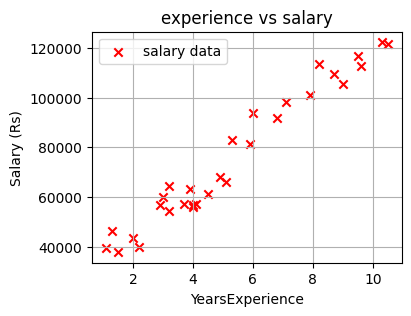

In [ ]:
#plot
plt.figure(figsize=(4,3))
plt.scatter(sd['YearsExperience'], sd['Salary'], c='r', marker='x', label='salary data')
plt.title('experience vs salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary (Rs)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#DIVIDE THE WHOLE DATASET INTO FEATURE(INDEPENDENT) AND TARGET(DEPENDENT)
x = sd['YearsExperience'].values.reshape(-1,1)
y = sd['Salary'].values.reshape(-1,1)

In [ ]:
#further dividing this x and y into training sets and testing sets
from sklearn.model_selection import train_test_split

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=100)

In [ ]:
xtrain

array([[ 4.1],
       [ 2.9],
       [ 4. ],
       [ 9.6],
       [ 9. ],
       [ 3. ],
       [ 5.3],
       [ 7.9],
       [ 4. ],
       [ 2.2],
       [10.5],
       [ 1.1],
       [ 1.3],
       [ 5.9],
       [ 4.5],
       [ 6. ],
       [ 7.1],
       [ 1.5],
       [ 6.8],
       [ 3.9],
       [ 5.1],
       [ 4.9],
       [ 8.2],
       [ 3.2],
       [ 2. ],
       [ 8.7],
       [ 3.2]])

In [ ]:
#importing the models
from sklearn.linear_model import LinearRegression

In [ ]:
LR= LinearRegression()
LR

LinearRegression()

In [ ]:
#training the model
LR.fit(xtrain,ytrain)

LinearRegression()

In [ ]:
#PREDICTING THE VALUES
ypred = LR.predict(xtest)
ypred

array([[ 60915.63025738],
       [115503.13308223],
       [123032.4438167 ]])

In [ ]:
ytest

array([[ 57189.],
       [116969.],
       [122391.]])

In [ ]:
#calculating the Sum of Squared Errors
from sklearn.metrics import mean_squared_error

In [ ]:
mse = mean_squared_error(ypred, ytest)
mse

5482663.021923073

In [ ]:
rmse = np.sqrt(mse)
rmse

np.float64(2341.508706352183)

In [ ]:
import pickle

In [ ]:
pickle.dump(LR, open("salary_model.pk1", 'wb'))

In [ ]:
pip install gradio


In [ ]:
import gradio as gr

In [ ]:
#GRADIO UI FOR SALARY PREDICTION
def salary_prediction(exp):
  exp_array=np.array(float(exp)).reshape(-1,1)
  predicted_salary=LR.predict(exp_array)[0]

  plt.figure(figsize==(10,8))
  plt.scatter(xtrain,ytrain,c='r',label='training data')
  plt.scatter(xtest,ytest,c='g',label='testing data')

  x_range = np.linspace(0,11,10,100)
  y_pred = LR.predict(x_range.reshape)
  plt.plot(x_range,y-pred, color='b',label='linear regression line')
  plt.scatter(exp, predicted_salary, c='purple',marker='x',label=f'predicted salary for {exp}years: Rs{predicted_salary}')
  plt.title('experience vs salary')
  plt.xlabel('years of experience')
  plt.ylabel('salary')
  plt.legend()
  plt.grid(True)

  plot_path='/content/Salary Plot.png'
  plt.savefig(plot-path)
  plt.close()

  return f'predicted salary: Rs(predicted_salary)',plot_path

In [ ]:
iface = gr.Interface(
    fn=salary_prediction,
    inputs=gr.Number(label='yers of experience'),
    outputs=[gr.Textbox(label='predicted salary'),gr.Image(label='linear regression plot')],
    title='salary predictor',
)

In [ ]:
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2226932b922967cb28.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
import random

In [1]:
pip install gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.0 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [2]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.1 which is incompatible.


In [5]:
import gradio as gr
from gtts import gTTS

In [6]:
p1 = input('enter your name: ')
p2 = input('enter your friend name: ')

fc = random.randint(0,100)

print(f'the friendship bonding between {p1} and {p2} is {fc}%')

enter your name: riya
enter your friend name: diya
the friendship bonding between riya and diya is 43%


In [7]:
def frnd_calc(p1, p2):
    fc = random.randint(0, 100)
    result = f"The friendship bonding between {p1} and {p2} is {fc}%"
    text = gTTS(result)
    audio = 'result.mp3'
    text.save(audio)
    return result,audio

interface = gr.Interface(
    fn=frnd_calc,
    inputs=[
        gr.Textbox(label="Your Name:"),
        gr.Textbox(label="Friend's Name:")
    ],
    outputs=[gr.Textbox(label="Friendship Percentage"),gr.Audio(label='result in audio')],
    title="Friendship Calculator"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8ab326f1cf99b2b2f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
